# Phần 3 - Phân Tích So Sánh và Kỹ Năng Nghiên Cứu

Notebook này triển khai toàn bộ phần code phục vụ viết báo cáo Phần 3:

1. Kết nối hồi quy - phân lớp theo khung GLM (Generalized Linear Models).
2. Bảng so sánh toàn diện các nhóm mô hình.
3. Phân tích độ nhạy/tính bền vững (split sensitivity, noise injection, feature corruption, convergence).
4. Tái hiện thí nghiệm (seed cố định, ghi log, lưu split indices, đo thời gian/bộ nhớ, snapshot môi trường).


In [1]:
import os
from pathlib import Path
from part3_pipeline import run_all

results = run_all(seed=42, max_class_samples=30000)

repo_root = results['repo_root']
part3_results = results['part3_results']

# Display relative path for portability
try:
    rel_path = part3_results.relative_to(repo_root.parent)
except ValueError:
    rel_path = part3_results

print('Pipeline finished.')
print('Output dir (relative):', rel_path)
print('Manifest counts:', results['manifest']['counts'])


d:\HỌC KÌ 6\NHẬP MÔN HỌC MÁY\THỰC HÀNH - BÀI TẬP\ĐỒ ÁN 1\supervised-learning-project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
d:\HỌC KÌ 6\NHẬP MÔN HỌC MÁY\THỰC HÀNH - BÀI TẬP\ĐỒ ÁN 1\supervised-learning-project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
d:\HỌC KÌ 6\NHẬP MÔN HỌC MÁY\THỰC HÀNH - BÀI TẬP\ĐỒ ÁN 1\supervised-learning-project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
d:\HỌC KÌ 6\NHẬP MÔN HỌC MÁY\THỰC HÀNH - BÀI TẬP\ĐỒ ÁN 1\supervised-learning-project\.venv\Lib\site-packages\sklearn\discriminant_analysis.py:935: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Pipeline finished.
Output dir: D:\HỌC KÌ 6\NHẬP MÔN HỌC MÁY\THỰC HÀNH - BÀI TẬP\ĐỒ ÁN 1\supervised-learning-project\code\Part3_Comparison\results
Manifest counts: {'split_records': 21, 'noise_records': 28, 'corruption_records': 63}


In [2]:
display(results['reg_summary_df'])
display(results['cls_summary_df'])
display(results['comparison_table'])


,Model,MSE_test,RMSE_test,MAE_test,R2_test
0,Polynomial,0.342813,0.585503,0.442064,0.828385
1,Lasso,0.349221,0.590949,0.447529,0.825177
2,ElasticNet,0.349259,0.590982,0.447614,0.825158
3,Ridge,0.349292,0.591009,0.447535,0.825142
4,Fourier,0.349341,0.591051,0.447499,0.825117
5,OLS (Normal Eq.),0.349341,0.591051,0.447499,0.825117
6,Mini-batch GD,0.349637,0.591301,0.447170,0.824969
7,WLS,0.369868,0.608168,0.429387,0.814841
8,RBF,0.798783,0.893747,0.693265,0.600123


,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
0,LDA,0.679853,0.486090,0.579241,0.512252
1,Logistic One-vs-One,0.694956,0.614494,0.326947,0.331499
2,Logistic Direct Softmax,0.689199,0.324946,0.308579,0.299426
3,Logistic One-vs-Rest,0.676996,0.277177,0.294942,0.285181
4,Regularized Logistic L2 (custom from 03),0.679414,0.278544,0.292729,0.284697
5,Regularized Logistic L1 (custom from 03),0.678735,0.278531,0.291690,0.284119
6,QDA,0.223299,0.335466,0.544051,0.233464


,Tieu chi,Linear Reg.,Ridge/Lasso,Logistic Reg.,LDA/QDA
0,Gia thiet phan phoi,"Gaussian noise, E[y|X] linear",Nhu Linear Reg. + regularization prior,"Bernoulli/Categorical, logit/softmax link","Gaussian theo lop; LDA chung covariance, QDA r..."
1,Nghiem dang dong,Co (Normal Equation),Ridge: co; Lasso: khong (coord-descent),Khong (iterative: GD/Newton),Co (uoc luong thong ke + Bayes rule)
2,Do phuc tap huan luyen,Trung binh (giai he tuyen tinh),Cao hon Linear (CV + regularization),Trung binh-den-cao (iterative optimization),LDA nhe; QDA nang hon do covariance theo lop
3,Kha nang giai thich,Rat cao,Cao (Lasso co tinh chat chon dac trung),Cao (he so theo log-odds),Trung binh-cao (tham so phan phoi theo lop)
4,Nhay voi outlier,Cao (MSE rat nhay),Ridge/Lasso giam mot phan nhung van nhay,Nhay voi outlier leverage cao,Nhay do phu thuoc uoc luong mean/covariance
5,Hieu nang thuc nghiem,Best R2=0.8251 (OLS (Normal Eq.)),Best R2=0.8252 (Lasso),Best F1-macro=0.3315 (Logistic One-vs-One),Best F1-macro=0.5123 (LDA)


## Minh họa kết nối GLM

Logistic Regression là hồi quy trên không gian log-odds:

- Linear predictor: $\eta = Xw + b$
- Logit link: $\log\frac{p}{1-p} = \eta$

Cell dưới đây minh họa tính tuyến tính giữa $\eta$ và $\text{logit}(p)$ trên dữ liệu phân lớp thực tế.


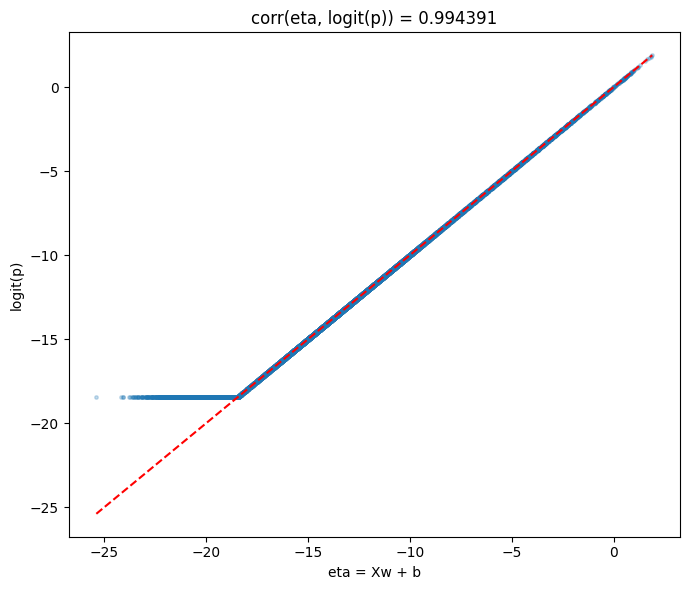

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_cls_all = np.vstack([
    results['cls_artifacts']['X_train_processed'],
    results['cls_artifacts']['X_val_processed'],
    results['cls_artifacts']['X_test_processed'],
])
y_cls_all = np.concatenate([
    results['cls_artifacts']['y_train'],
    results['cls_artifacts']['y_val'],
    results['cls_artifacts']['y_test'],
])

rare_class = int(pd.Series(y_cls_all).value_counts().idxmin())
y_bin = (y_cls_all == rare_class).astype(int)
subset_idx, _ = train_test_split(
    np.arange(len(y_bin)),
    train_size=min(30000, len(y_bin)),
    stratify=y_bin,
    random_state=42,
)

X_bin = X_cls_all[subset_idx]
y_bin_sub = y_bin[subset_idx]
model = LogisticRegression(max_iter=300, solver='lbfgs', random_state=42)
model.fit(X_bin, y_bin_sub)
eta = model.decision_function(X_bin)
proba = model.predict_proba(X_bin)[:, 1]
proba = np.clip(proba, 1e-8, 1 - 1e-8)
logit = np.log(proba / (1.0 - proba))
corr = float(np.corrcoef(eta, logit)[0, 1])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(eta, logit, s=6, alpha=0.25)
line_min = min(eta.min(), logit.min())
line_max = max(eta.max(), logit.max())
ax.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=1.5)
ax.set_title(f'corr(eta, logit(p)) = {corr:.6f}')
ax.set_xlabel('eta = Xw + b')
ax.set_ylabel('logit(p)')
plt.tight_layout()
plt.show()


train_ratio                      0.6       0.7       0.8
dataset        model                                    
classification LDA          0.497939  0.490470  0.489110
               LogisticReg  0.512129  0.525932  0.484579
               QDA          0.554737  0.558262  0.551325
regression     Lasso        0.820189  0.815775  0.813554
               OLS          0.820297  0.815756  0.813318
               Polynomial   0.823888  0.820498  0.817939
               Ridge        0.820175  0.815786  0.813462

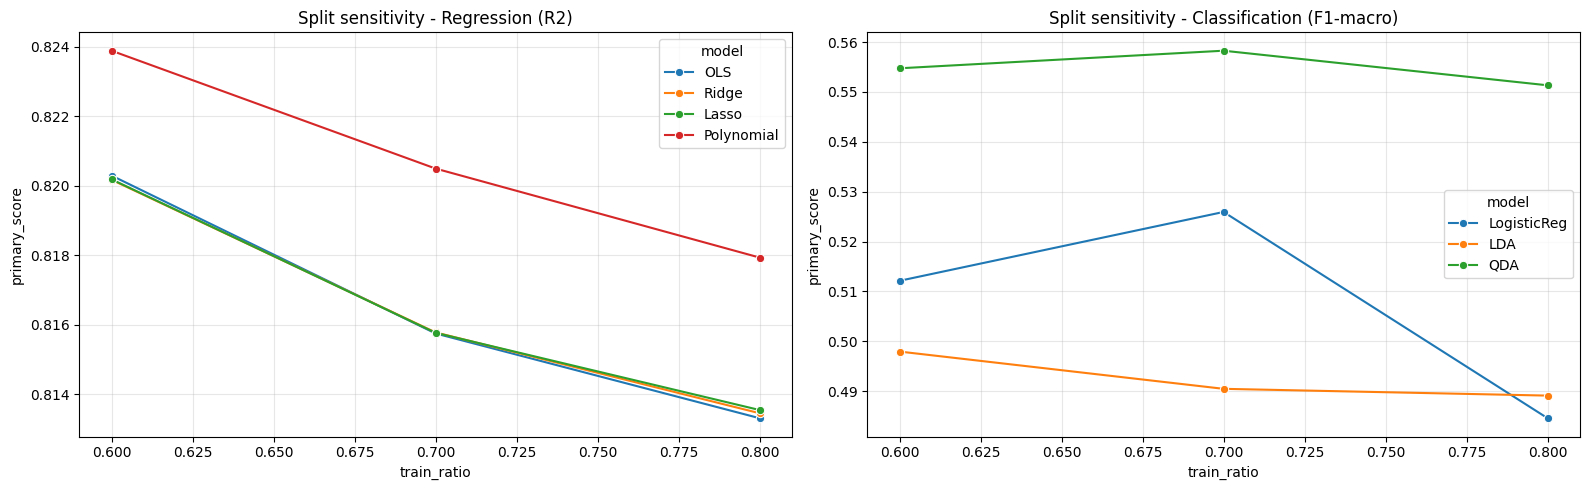

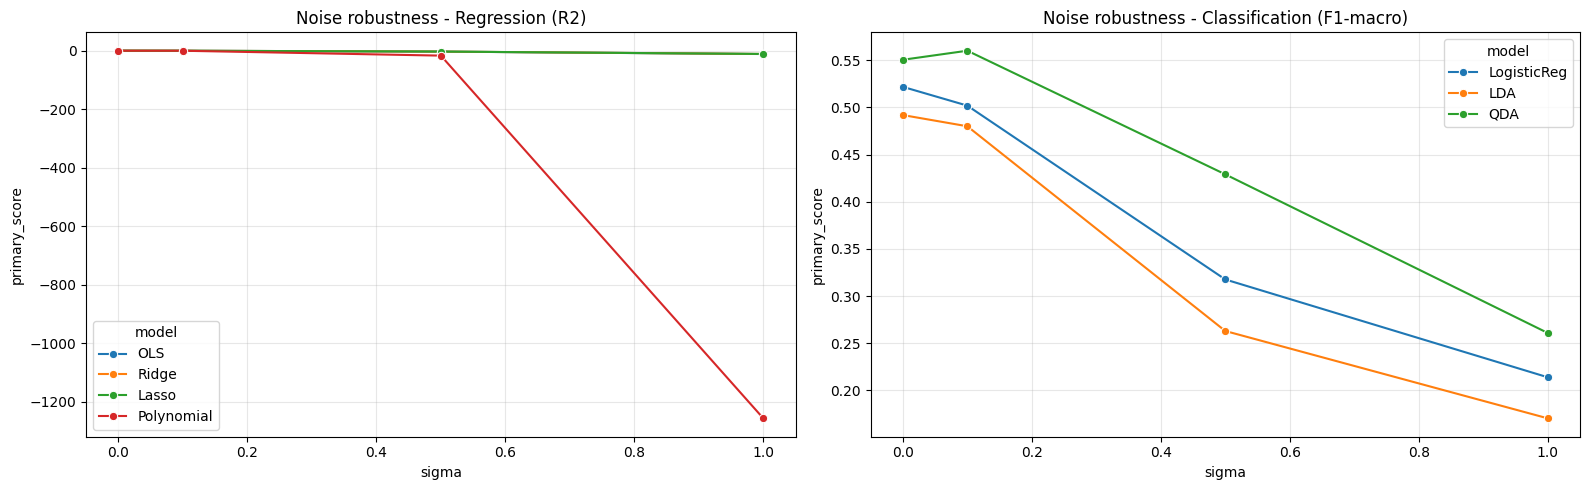

corruption_rate                             0.1       0.2       0.3
dataset        model       imputation                              
classification LDA         knn         0.488895  0.489751  0.480617
                           mean        0.475592  0.467155  0.436440
                           median      0.466359  0.454592  0.431410
               LogisticReg knn         0.515999  0.502701  0.472580
                           mean        0.474518  0.440066  0.402627
                           median      0.485491  0.457572  0.408125
               QDA         knn         0.554719  0.542832  0.528179
                           mean        0.540372  0.503678  0.465542
                           median      0.535207  0.505516  0.470623
regression     Lasso       knn         0.765574  0.712209  0.653387
                           mean        0.739972  0.659053  0.589239
                           median      0.717405  0.610112  0.501716
               OLS         knn         0.765202  0.711692  0.652953
                           mean        0.739058  0.657460  0.587393
                           median      0.715929  0.606903  0.496372
               Polynomial  knn         0.768807  0.710984  0.651612
                           mean        0.732902  0.641196  0.554278
                           median      0.723151  0.618750  0.515575
               Ridge       knn         0.765520  0.712131  0.653383
                           mean        0.739613  0.658437  0.588515
                           median      0.716725  0.608463  0.498650

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

split_df = results['split_df']
noise_df = results['noise_df']
corruption_df = results['corruption_df']

display(split_df.pivot_table(index=['dataset', 'model'], columns='train_ratio', values='primary_score', aggfunc='mean'))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=split_df[split_df['dataset'] == 'regression'], x='train_ratio', y='primary_score', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Split sensitivity - Regression (R2)')
sns.lineplot(data=split_df[split_df['dataset'] == 'classification'], x='train_ratio', y='primary_score', hue='model', marker='o', ax=axes[1])
axes[1].set_title('Split sensitivity - Classification (F1-macro)')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=noise_df[noise_df['dataset'] == 'regression'], x='sigma', y='primary_score', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Noise robustness - Regression (R2)')
sns.lineplot(data=noise_df[noise_df['dataset'] == 'classification'], x='sigma', y='primary_score', hue='model', marker='o', ax=axes[1])
axes[1].set_title('Noise robustness - Classification (F1-macro)')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(corruption_df.pivot_table(index=['dataset', 'model', 'imputation'], columns='corruption_rate', values='primary_score', aggfunc='mean'))


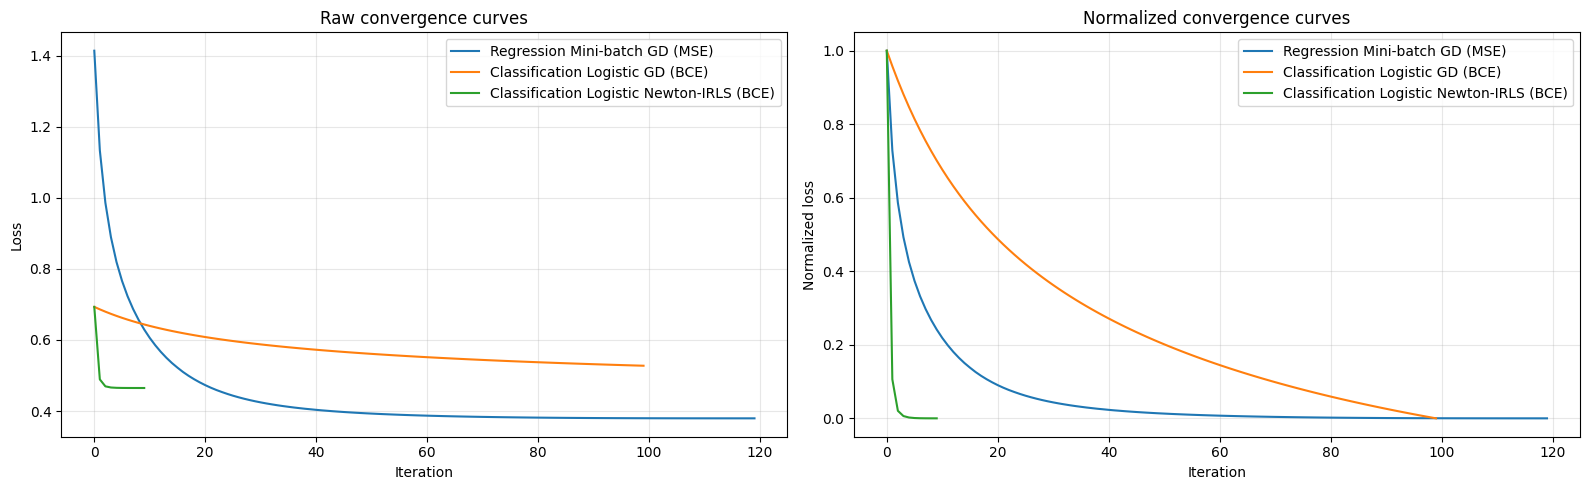

,algorithm,iterations,best_iteration,best_loss,final_loss
0,Regression Mini-batch GD (MSE),120,120,0.379353,0.379353
2,Classification Logistic Newton-IRLS (BCE),10,10,0.464768,0.464768
1,Classification Logistic GD (BCE),100,100,0.527488,0.527488


In [5]:
curves = results['curves']
convergence_df = results['convergence_df']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name, curve in curves.items():
    axes[0].plot(curve, label=name)
    norm_curve = (curve - np.min(curve)) / (np.max(curve) - np.min(curve) + 1e-12)
    axes[1].plot(norm_curve, label=name)
axes[0].set_title('Raw convergence curves')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[1].set_title('Normalized convergence curves')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Normalized loss')
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

display(convergence_df)


## Các file đầu ra

Sau khi chạy notebook, các file phục vụ báo cáo được lưu tại thư mục tương đối:

```
supervised-learning-project/code/Part3_Comparison/results/
```

Bao gồm:
- `part3_comprehensive_comparison_table.csv` - Bảng so sánh toàn diện
- `split_sensitivity_results.csv` - Kết quả thí nghiệm sensitivity analysis
- `noise_robustness_results.csv` - Kết quả thí nghiệm noise injection
- `corruption_robustness_results.csv` - Kết quả thí nghiệm feature corruption
- `convergence_summary.csv` - Tóm tắt khả năng hội tụ
- `experiment_log.jsonl` - Log thực nghiệm (JSON Lines)
- `split_indices.npz` - Chỉ số phân chia (NumPy compressed)
- `environment_snapshot.txt` - Snapshot môi trường thực thi
- `part3_manifest.json` - Manifest tổng hợp toàn bộ artifact
